In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_scatter import scatter_add, scatter_mean
from torch.utils.data import Dataset, DataLoader
from torch.nn import Sequential, Linear, ReLU, LayerNorm
import torch.nn.functional as F
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import imageio
from tqdm.notebook import tqdm
import random
import pickle
import shutil
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# DOWNLOAD THE DATASET

In [ ]:
import gdown

# Extracting the file
file_id = "1mjArnL1LJoBKwywzO9w1zTuc3Ra60boN"
gdown.download(
    f"https://drive.google.com/uc?id={file_id}", output="DATA.zip", quiet=False
)

# Extract the downloaded zip file
import zipfile

with zipfile.ZipFile("DATA.zip", "r") as zip_ref:
    zip_ref.extractall("./DATA")

print("Download and extraction complete!")

Downloading...
From: https://drive.google.com/uc?id=1mjArnL1LJoBKwywzO9w1zTuc3Ra60boN
To: /home/visharma/gnn/FENICS/SEM_PROJECT/DATA.zip
100%|██████████| 13.8M/13.8M [00:00<00:00, 52.3MB/s]


Download and extraction complete!


# Understanding the Simulation Data

## Overview
The dataset consists of `.pt` files, which store the simulation roll-out trajectory of a beam over **50 time steps**. Each file represents a different simulation condition.

## File Naming Convention
The file name encodes important parameters of the beam simulation. For example:


This corresponds to:

- **Beam Geometry**:
  - **Length (L)** = 1.0 m
  - **Width (W)** = 0.1 m
  - **Depth (D)** = 0.04 m
  - **Discretization**: 8 elements along the length, 2 along the width and depth.

- **Material Properties**:
  - **Young's Modulus (E)** = 1000.0
  - **Poisson's Ratio (ν)** = 0.3
  - **Density (ρ)** = 1.0
  - **Damping Parameters**:
    - **em** = 0.01
    - **ek** = 0.01

- **Simulation Conditions**:
  - **Initial Force (Pi)** = 1.2 (linearly increasing force)
  - **Total Simulation Time (T)** = 4.0 sec
  - **Time at which Force Reaches Max (Tc)** = 1.2 sec
  - **Number of Time Steps (Nsteps)** = 50
  - **Time Step Size**: \( \frac{4.0}{50} = 0.08 \) sec

## Data Structure
Each `.pt` file is a **Dataloader object** containing **50 graph representations**, where each graph corresponds to the state of the beam at a specific time step.


In [ ]:
# Get the current working directory
cwd_path = os.curdir

# Define the path to the training dataset directory
train_path = os.path.join(cwd_path, "DATA/Results/train")

# Path where graph data files (.pt) are stored
graph_dir = os.path.join(train_path, "graphs")

# List all .pt files in the directory
graph_files = [
    os.path.join(graph_dir, f) for f in os.listdir(graph_dir) if f.endswith(".pt")
]

# Load all graph files as PyTorch objects (list of graph data for training)
graph_lists = [torch.load(f) for f in graph_files]

# Split the dataset:
# - `train_files` contains all but the last graph file for training
# - `interp_test_file` contains the last graph file for testing (interpolation task)
train_files = graph_files[0:-1]
interp_test_file = graph_files[-1:]

## Exploring the Dataset

### **Objectives**
In this section, we:
1. **Print the list of graph files** loaded from the dataset directory.
2. **Load a `.pt` file** using `torch.load()` to examine its contents.
3. **Convert the dataloader object into a list** to confirm that it contains 50 graph states (one per time step).
4. **Extract and analyze the 10th graph** from the dataset to inspect its fields.

### **Expected Outcome**
- The script will print all the `.pt` files in the dataset.
- It will confirm that each `.pt` file contains 50 graphs.
- Finally, it will print the structure of the 10th graph, helping us understand its format and fields.


In [ ]:
import torch

# Print all the graph file names read from the DATA directory
print("Graph Files in Dataset:")
for file in graph_files:
    print(file)

# Load the .pt file (Dataloader object)
graph_data_loader = torch.load(graph_files[0])  # Load the first file as an example

# Convert the dataloader object to a list to verify the number of time steps (should be 50)
graph_list = list(graph_data_loader)
print(f"\nTotal Graphs in Loaded Data: {len(graph_list)}")  # Should print 50

# Retrieve the 10th graph (index 9 since Python indexing starts at 0)
graph_sample = graph_list[9]
print("\nFields in the 10th Graph:")
print(graph_sample)  # This will display the graph structure and its fields


Graph Files in Dataset:
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.0_T4.0_Tc0.4_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.1_T4.0_Tc0.8_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.2_T4.0_Tc0.8_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.2_T4.0_Tc1.2_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.1_T4.0_Tc1.2_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.0_T4.0_Tc0.8_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.01_Pi1.2_T4.0_Tc0.4_Nsteps50.pt
./DATA/Results/train/graphs/graphsL1.0_W0.1_D0.04_NL8_NW2_ND2_E1000.0_nu0.3_rho1.0_em0.01_ek0.

## Understanding the Graph Features

Each graph in the dataset represents the state of the beam at a specific time step and contains the following features:

### **Graph Input Features**
- **`graph.time`**: The timestamp of the simulation (in seconds).
- **`graph.x`**: Positions of nodes at the given timestamp.
- **`graph.x_vel_t`**: Velocities of nodes at the given timestamp.
- **`graph.x_node_force`**: External forces applied to the nodes.
  - Only end nodes receive a force, while internal nodes have `0`.
- **`graph.x_bc`**: A scalar variable indicating boundary conditions:
  - `1` → Fixed node  
  - `0` → Free node
- **`graph.x_element_connectivity`**: Defines the mesh connectivity by listing nodes forming each element.

### **Graph Target Variables (Outputs to Predict)**
- **`graph.y_acc_t`**: Acceleration of each node at time `t` (3-dimensional).
- **`graph.y_sig_t`**: Stress tensor at each node at time `t` (6-dimensional).

### **Prediction Strategy**
In this dynamical system task, we predict the future state based on the current and past states. There are two common approaches:

1. **Direct Future Prediction**:  
   - Use features at time `t` to directly predict the next step's position (`x_t+1`) and velocity (`v_t+1`).

2. **Acceleration-Based Integration**:  
   - Predict the **acceleration** (`a_t`) at time `t`.
   - Use Newtonian kinematics to integrate and estimate the future state:

   \[
   v_{t+1} = v_t + a_t \cdot dt
   \]

   \[
   x_{t+1} = x_t + v_t \cdot dt + \frac{1}{2} a_t \cdot dt^2
   \]

   - This method ensures physics-based consistency in motion updates.

### **Modeling Approach**
- We will use the **current and past time step features** to:
  1. Predict **acceleration** at the current time step (`a_t`).
  2. Predict **stress tensor** at the current time step (`σ_t`).
  3. Integrate acceleration (`a_t`) to compute the **new position** (`x_t+1`) and **velocity** (`v_t+1`).

This methodology is from the paper **MeshGraphNets**

In [ ]:
# The stress tensor is stored as a flattened 1D array but represents a 3x3 symmetric matrix.
# We reshape it back into a matrix to inspect its structure.

# Display the first node's stress tensor as a 3x3 matrix
stress_tensor_matrix = graph_sample.y_sig_t[0].view(3, 3)
print(
    "Stress Tensor (3x3 Symmetric Matrix) for the First Node:\n", stress_tensor_matrix
)

Stress Tensor (3x3 Symmetric Matrix) for the First Node:
 tensor([[ 3.5462,  0.7243, -0.1913],
        [ 0.7243,  0.8246,  0.0173],
        [-0.1913,  0.0173,  1.2217]])


In [6]:
# acceleration is a 3D vector for each node
graph_sample.y_acc_t[0:5]

tensor([[ 6.9175e-20,  5.0668e-18,  4.8548e-19],
        [-9.1163e-02, -1.9109e-01, -1.7655e-02],
        [-1.1459e-01, -5.1578e-01, -3.7036e-02],
        [-6.9285e-02, -8.0574e-01, -3.7801e-02],
        [ 2.7364e-02, -8.6983e-01, -1.2857e-02]])

## Creating a DataLoader for Graph-Based Dynamics Modeling

### **Objective**
We need to structure our dataset in a way that enables models to learn from past time steps and predict future states. This requires forming **graph triplets**:
- **Previous time step (`t-1`)**
- **Current time step (`t`)**
- **Next time step (`t+1`)**

These triplets are used as input-output pairs for training the model.

---

### **Dataset: `GraphPairDataset`**
This dataset:
1. Loads the simulation graphs from `.pt` files.
2. Extracts **time-step-based graph triplets** `(previous, current, next)`.
3. Stores these triplets in a list to be accessed during training.

#### **Data Loading Process**
- The dataset iterates through `.pt` files containing **50 time steps of simulation**.
- For each file, it extracts consecutive graphs in **triplets**: `(t-1, t, t+1)`.
- The dataset allows the model to learn **how the system evolves over time**.

---

### **Batching: `custom_collate_fn`**
- Since we are using **torch_geometric**, we must batch graph objects properly.
- `custom_collate_fn` takes a batch of triplets and **groups previous, current, and next graphs separately**.
- This ensures that all graphs within a batch are processed correctly.

---

### **Creating the DataLoader**
The `create_dataloader` function:
- Instantiates the `GraphPairDataset`.
- Uses `DataLoader` to efficiently batch and shuffle the data.
- Uses `drop_last=True` to discard any incomplete batches (ensuring batch size consistency).

---

### **Usage Example**
```python
train_dataloader = create_dataloader(train_files, batch_size=4)
for prev_batch, curr_batch, next_batch in train_dataloader:
    print(prev_batch, curr_batch, next_batch)  # Process batched graphs
    break  # Just check one batch


In [ ]:
class GraphPairDataset(Dataset):
    """
    Dataset class for creating graph data pairs (previous, current, next time steps).
    This helps in training models that use past states to predict future states.
    """

    def __init__(self, graph_files):
        """
        Initialize the dataset with a list of graph DataLoader files.
        Each graph file contains 50 time steps of simulation data.
        """
        self.graph_pairs = []  # Stores tuples of (previous, current, next) graphs

        # Load graphs from each .pt file and generate (previous, current, next) pairs
        for file_path in graph_files:
            graphs = list(torch.load(file_path))  # Convert DataLoader to list

            # Generate graph triplets: (t-1, t, t+1)
            for t in range(1, len(graphs) - 1):
                previous_graph = graphs[t - 1]
                current_graph = graphs[t]
                next_graph = graphs[t + 1]
                self.graph_pairs.append((previous_graph, current_graph, next_graph))

    def __len__(self):
        """Return the total number of graph pairs available in the dataset."""
        return len(self.graph_pairs)

    def __getitem__(self, idx):
        """Retrieve the (previous, current, next) graph triplet at index `idx`."""
        return self.graph_pairs[idx]


def custom_collate_fn(batch):
    """
    Custom collate function to batch graph data objects.
    Groups previous, current, and next graphs into separate batches.
    """
    previous_graphs, current_graphs, next_graphs = zip(*batch)
    return (
        Batch.from_data_list(previous_graphs),
        Batch.from_data_list(current_graphs),
        Batch.from_data_list(next_graphs),
    )


def create_dataloader(graph_files, batch_size=4, shuffle=True):
    """
    Function to create a PyTorch DataLoader for training.

    Parameters:
    - graph_files: List of .pt files containing graph data.
    - batch_size: Number of graph triplets per batch (default=4).
    - shuffle: Whether to shuffle the dataset (default=True).

    Returns:
    - A DataLoader object ready for training.
    """
    dataset = GraphPairDataset(graph_files)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=custom_collate_fn,
        drop_last=True,  # Ensures all batches have the same size
    )
    return dataloader

## Creating and Verifying the DataLoader

### **DataLoader Configuration**
- **Training DataLoader (`train_dataloader`)**:
  - Batch size = **10** (each batch contains **10 triplets** of (previous, current, next) graphs).
  - Used for training the model in batches.

- **Testing DataLoader (`test_dataloader`)**:
  - Batch size = **1** (we will do a **rollout** for time-step predictions starting from the initial graph).
  - No shuffling (`shuffle=False`) to maintain sequential order during testing.

---

### **Verifying the Data Order**
To ensure that the DataLoader was correctly created, we:
1. Take a batch from `train_dataloader`.
2. Print the **time steps** of the previous, current, and next graphs.
3. Confirm that the time steps are **sequentially ordered**.

---

### **Expected Output**
For a batch size of 10, we should see something like:

In [ ]:
# Create DataLoaders for training and testing
# Training batch size is 10, meaning each batch contains 10 sequences of (previous, current, next) graphs
train_dataloader = create_dataloader(train_files, batch_size=16)

# Testing batch size is 1 since we will perform a full rollout step-by-step
test_dataloader = create_dataloader(interp_test_file, batch_size=1, shuffle=False)

# Verifying if the DataLoader maintains the correct order of time steps
for previous_graph, current_graph, next_graph in train_dataloader:
    print("Previous Graph Time Steps:", f"{previous_graph.time}")
    print("Current Graph Time Steps:", f"{current_graph.time}")
    print("Next Graph Time Steps:", f"{next_graph.time}")
    break  # Checking only the first batch

# The output confirms that the time steps are correctly ordered.
# Since batch_size=10, each batch contains 10 triplets of (previous, current, next) graphs.


Previous Graph Time Steps: tensor([0.5600, 2.5600, 3.6800, 1.2800, 1.7600, 1.9200, 2.6400, 2.8000, 3.2800,
        0.8000, 2.5600, 0.4000, 3.5200, 2.0800, 3.1200, 3.3600])
Current Graph Time Steps: tensor([0.6400, 2.6400, 3.7600, 1.3600, 1.8400, 2.0000, 2.7200, 2.8800, 3.3600,
        0.8800, 2.6400, 0.4800, 3.6000, 2.1600, 3.2000, 3.4400])
Next Graph Time Steps: tensor([0.7200, 2.7200, 3.8400, 1.4400, 1.9200, 2.0800, 2.8000, 2.9600, 3.4400,
        0.9600, 2.7200, 0.5600, 3.6800, 2.2400, 3.2800, 3.5200])


In [ ]:
# we do the same check for test_dataloader
for previous_graph, current_graph, next_graph in test_dataloader:
    print("Previous Graph:", f"{previous_graph.time}")
    print("Current Graph:", f"{current_graph.time}")
    print("Next Graph:", f"{next_graph.time}")
    break

Previous Graph: tensor([0.0800])
Current Graph: tensor([0.1600])
Next Graph: tensor([0.2400])


# INPUT DATA SCALING : CALCULATE MEAN AND STD.DEV

In [ ]:
def cal_std_mean(data):
    """
    Calculate the standard deviation and mean along the first dimension.

    Parameters:
    - data (Tensor): A tensor containing feature values.

    Returns:
    - Tuple (std, mean) for the given data.
    """
    return data.std(dim=0), data.mean(dim=0)


def cal_data_stats(train_file_paths):
    """
    Compute statistics (mean and standard deviation) for various features
    from the training dataset.

    This is useful for normalizing the data before feeding it into the model.

    Parameters:
    - train_file_paths (list of str): Paths to the .pt files containing graph data.

    Returns:
    - stat_in_feat: Tuple containing (std, mean) for input features.
    - stat_out_feat: Tuple containing (std, mean) for output features.
    """

    # Initialize lists to collect data across all graphs
    x_pos_t = []  # Node positions
    x_vel_t = []  # Node velocities
    x_node_force = []  # External forces applied to nodes
    y_acc_t = []  # Node accelerations (output feature)
    y_sig_t = []  # Stress tensor at nodes (output feature)
    edge_dx_list = []  # Edge rel. dist vector (edge feature)
    mag_edge_dx_list = []  # Magnitude of edge rel. vector (edge feature)

    # Loop through each graph file and extract feature data
    for file_path in train_file_paths:
        graph_dataloader = torch.load(file_path)  # Load the DataLoader
        lst_graph = list(graph_dataloader)  # Convert the DataLoader to a list of graphs

        for graph in lst_graph:
            senders, receivers = graph.edge_index  # Get connectivity (edge list)
            edge_dx = graph.x[receivers] - graph.x[senders]  # Compute edge differences
            mag_edge_dx = edge_dx.norm(dim=1, keepdim=True)  # Compute edge magnitudes

            # Collect feature values from the graph
            x_pos_t.append(graph.x)
            x_vel_t.append(graph.x_vel_t)
            x_node_force.append(graph.x_node_force)
            y_acc_t.append(graph.y_acc_t)
            y_sig_t.append(graph.y_sig_t)
            edge_dx_list.append(edge_dx)
            mag_edge_dx_list.append(mag_edge_dx)

    # Concatenate data across all graphs for statistical computation
    all_pos = torch.cat(x_pos_t, dim=0)
    all_vel = torch.cat(x_vel_t, dim=0)
    all_force = torch.cat(x_node_force, dim=0)
    all_acc = torch.cat(y_acc_t, dim=0)
    all_sig = torch.cat(y_sig_t, dim=0)
    all_edge_dx = torch.cat(edge_dx_list, dim=0)
    all_mag_edge_dx = torch.cat(mag_edge_dx_list, dim=0)

    # Compute standard deviation and mean for each feature
    std_pos, mean_pos = cal_std_mean(all_pos)
    std_vel, mean_vel = cal_std_mean(all_vel)
    std_fext, mean_fext = cal_std_mean(all_force)
    std_acc, mean_acc = cal_std_mean(all_acc)
    std_sig, mean_sig = cal_std_mean(all_sig)
    std_edge_dx, mean_edge_dx = cal_std_mean(all_edge_dx)
    std_mag_edge_dx, mean_mag_edge_dx = cal_std_mean(all_mag_edge_dx)

    # Package input and output feature statistics for easy access
    stat_in_feat = (
        (std_pos, mean_pos),
        (std_vel, mean_vel),
        (std_fext, mean_fext),
        (std_edge_dx, mean_edge_dx),
        (std_mag_edge_dx, mean_mag_edge_dx),
    )

    stat_out_feat = ((std_acc, mean_acc), (std_sig, mean_sig))

    return stat_in_feat, stat_out_feat


# Compute dataset statistics
stat_in_feat, stat_out_feat = cal_data_stats(train_files)

# Print results for verification
print("Input Feature Stats:", stat_in_feat)
print("Output Feature Stats:", stat_out_feat)


Input Feature Stats: ((tensor([0.3228, 0.0561, 0.0174]), tensor([0.5000, 0.0557, 0.0195])), (tensor([0.0166, 0.2062, 0.0293]), tensor([ 2.0311e-06,  1.1167e-03, -4.1776e-04])), (tensor([0.0000, 0.1038, 0.0000]), tensor([0.0000, 0.0142, 0.0000])), (tensor([0.0951, 0.0365, 0.0141]), tensor([ 4.3317e-12,  1.0721e-11, -9.3674e-12])), (tensor([0.0457]), tensor([0.0922])))
Output Feature Stats: ((tensor([0.1216, 1.2729, 0.1474]), tensor([6.0442e-06, 2.2517e-03, 2.8299e-03])), (tensor([6.6414, 2.5704, 0.4625, 2.5704, 2.2547, 0.1118, 0.4625, 0.1118, 2.2096]), tensor([-0.0739,  0.1716, -0.0045,  0.1716, -0.0920,  0.0002, -0.0045,  0.0002,
        -0.0402])))


In [ ]:
def build_mlp_d(
    in_size,
    hidden_size,
    out_size,
    num_layers=1,
    lay_norm=True,
    use_sigmoid=False,
    use_softmax=False,
):
    """
    Builds a multi-layer perceptron (MLP) with configurable depth and optional layer normalization and sigmoid or softmax activation.

    Args:
        in_size (int): The size of the input feature vector.
        hidden_size (int): The size of the hidden layers.
        out_size (int): The size of the output layer.
        num_layers (int): The number of layers in the MLP.
        lay_norm (bool): Flag to add layer normalization after the last linear layer.
        use_sigmoid (bool): Flag to add a sigmoid activation layer at the output.
        use_softmax (bool): Flag to add a softmax activation layer at the output.

    Returns:
        nn.Module: The constructed MLP model.

    Raises:
        ValueError: If both use_sigmoid and use_softmax are True.
    """
    if use_sigmoid and use_softmax:
        raise ValueError("Only one of use_sigmoid or use_softmax can be true.")

    layers = [nn.Linear(in_size, hidden_size), nn.ReLU()]

    # Add intermediate layers
    for _ in range(num_layers - 1):
        layers.append(nn.Linear(hidden_size, hidden_size))
        layers.append(nn.ReLU())

    # Add the output layer
    layers.append(nn.Linear(hidden_size, out_size))

    # Create the MLP module
    module = nn.Sequential(*layers)

    # Optionally add layer normalization
    if lay_norm:
        module = nn.Sequential(module, nn.LayerNorm(normalized_shape=out_size))

    # Optionally add sigmoid activation
    if use_sigmoid:
        module = nn.Sequential(module, nn.Sigmoid())

    # Optionally add softmax activation
    if use_softmax:
        module = nn.Sequential(module, nn.Softmax(dim=-1))

    return module

# MODEL : MESHGRAPHNET:  ENCODE-PROCESS-DECODE

## MeshGraphNet Model

### **Model Components**
1. **Encoder**
   - Transforms raw node and edge features into a latent representation using MLPs.

2. **Graph Network Block**
   - Message passing between nodes via connected edges.
   - Aggregates received messages and updates node states.

3. **Decoder**
   - Predicts:
     - Acceleration (`3D vector` per node).
     - Stress tensor (`6D symmetric matrix` per node).

4. **GNS Model**
   - Combines encoding, message-passing, and decoding.
   - Uses multiple message-passing steps (`num_msgs`) to refine predictions.

---

### **Expected Output**
- `node_dacc`: Node accelerations at time `t`.
- `node_dsig`: Stress tensor predictions at time `t`.

This architecture follows the **MeshGraphNet** paradigm for physics-based learning.


In [ ]:
class Encoder(torch.nn.Module):
    """
    Encoder for node and edge features.

    - Encodes input node and edge features into latent space.
    - Uses Multi-Layer Perceptron (MLP) with layer normalization.

    Parameters:
    - `latent_size`: Size of the latent space.
    """

    def __init__(self, latent_size=128):
        super(Encoder, self).__init__()
        # Encode edge features (4 input features → latent space)
        self.edge_encoder = build_mlp_d(
            4, latent_size, latent_size, num_layers=1, lay_norm=True
        )

        # Encode node features (19 input features → latent space)
        self.node_encoder = build_mlp_d(
            19, latent_size, latent_size, num_layers=1, lay_norm=True
        )

    def forward(self, node_features, edge_features):
        """
        Forward pass: encode node and edge features.

        Returns:
        - `node_embedding`: Encoded node features.
        - `edge_embedding`: Encoded edge features.
        """
        node_embedding = self.node_encoder(node_features)
        edge_embedding = self.edge_encoder(edge_features)
        return node_embedding, edge_embedding


class GraphNetBlock(torch.nn.Module):
    """
    Graph network block for message passing.

    - Updates edge embeddings based on sender and receiver nodes.
    - Aggregates messages at the nodes.
    - Updates node embeddings with aggregated edge information.

    Parameters:
    - `latent_size`: Size of latent feature space.
    - `in_size_edge_MLP`: Input size for edge MLP.
    - `in_size_node_MLP`: Input size for node MLP.
    """

    def __init__(self, latent_size, in_size_edge_MLP, in_size_node_MLP):
        super(GraphNetBlock, self).__init__()
        self._latent_size = latent_size

        # Edge MLP: updates edge embeddings based on node interactions
        self.edge_net = build_mlp_d(
            in_size_edge_MLP, latent_size, latent_size, lay_norm=True
        )

        # Node MLP: updates node embeddings based on aggregated edge messages
        self.node_net = build_mlp_d(
            in_size_node_MLP, latent_size, latent_size, lay_norm=True
        )

    def forward(self, edge_index, node_embedding, edge_embedding):
        """
        Forward pass: message passing and node update.

        - `edge_index`: Edge connectivity (senders, receivers).
        - `node_embedding`: Node embeddings.
        - `edge_embedding`: Edge embeddings.

        Returns:
        - Updated node embeddings.
        - Updated edge embeddings.
        """
        senders, receivers = edge_index  # Extract sender and receiver node indices
        num_nodes = node_embedding.shape[0]

        # Compute new edge features using edge MLP
        edge_attr_ = self.edge_net(
            torch.hstack(
                (node_embedding[senders], node_embedding[receivers], edge_embedding)
            )
        )

        # Aggregate received edge messages at each node
        agg_received_edges = scatter_add(
            edge_attr_, receivers.long(), dim=0, dim_size=num_nodes
        )

        # Update node features using aggregated edge messages
        node_attr_ = self.node_net(torch.hstack((agg_received_edges, node_embedding)))

        # Add residual connections for stability
        new_node_embedding = node_attr_ + node_embedding
        new_edge_embedding = edge_attr_ + edge_embedding

        return new_node_embedding, new_edge_embedding


class Decoder(torch.nn.Module):
    """
    Decoder to predict acceleration and stress tensor from node embeddings.

    - Uses two separate MLPs:
      - One for acceleration (`3D output`).
      - One for stress tensor (`6D output`).

    Parameters:
    - `latent_size`: Size of latent feature space.
    """

    def __init__(self, latent_size=128):
        super(Decoder, self).__init__()
        self.acc_decoder = build_mlp_d(latent_size, latent_size, 3, lay_norm=False)
        self.sig_decoder = build_mlp_d(latent_size, latent_size, 6, lay_norm=False)

    def forward(self, node_embedding):
        """
        Forward pass: decode acceleration and stress tensor.

        Returns:
        - `decoded_acc`: Predicted acceleration (3D).
        - `decoded_stress_flat`: Flattened stress tensor (9D).
        """
        decoded_acc = self.acc_decoder(node_embedding)
        decoded_sig = self.sig_decoder(node_embedding)

        # we predict the 6 compoenets corresponding to the upper traingular elements of the symmetric 3x3 stress tensor (we can create the 9 element tensor from the 6 elements due to stress tensor)
        σ11, σ12, σ13, σ22, σ23, σ33 = (
            decoded_sig[:, 0],
            decoded_sig[:, 1],
            decoded_sig[:, 2],
            decoded_sig[:, 3],
            decoded_sig[:, 4],
            decoded_sig[:, 5],
        )

        # Construct the full 3x3 symmetric matrix
        decoded_stress_tensor = torch.stack(
            [
                torch.stack([σ11, σ12, σ13], dim=-1),
                torch.stack([σ12, σ22, σ23], dim=-1),
                torch.stack([σ13, σ23, σ33], dim=-1),
            ],
            dim=-2,
        )

        # Flatten the stress tensor for output
        decoded_stress_flat = decoded_stress_tensor.view(
            decoded_stress_tensor.size(0), -1
        )

        return decoded_acc, decoded_stress_flat


class MeshGraphNet(nn.Module):
    """
    MeshGraphNet Model.

    - Encodes node and edge features.
    - Processes them through multiple message-passing layers.
    - Decodes node-level properties (acceleration and stress tensor).

    Parameters:
    - `latent_size`: Size of latent feature space.
    - `num_msgs`: Number of message-passing steps.
    """

    def __init__(self, latent_size, num_msgs):
        super(MeshGraphNet, self).__init__()

        # Encoder for input graph data
        self.encoder = Encoder(latent_size)

        # Message-passing layers (GraphNetBlocks)
        self.processer_list = nn.ModuleList(
            [
                GraphNetBlock(
                    latent_size=latent_size,
                    in_size_edge_MLP=3
                    * latent_size,  # Edge MLP takes sender, receiver, and edge features
                    in_size_node_MLP=2 * latent_size,
                )  # Node MLP takes aggregated edge messages + current node features
                for _ in range(num_msgs)
            ]
        )

        # Decoder to predict acceleration and stress tensor
        self.decoder = Decoder(latent_size)

    def forward(self, ingraph):
        """
        Forward pass: Encodes, processes, and decodes graph data.

        Parameters:
        - `ingraph`: Input graph with node features `x` and edge features `edge_attr`.

        Returns:
        - Predicted node accelerations.
        - Predicted stress tensor.
        """
        node_features = ingraph.x
        edge_features = ingraph.edge_attr
        edge_index = ingraph.edge_index

        # Encode node and edge features
        node_embedding, edge_embedding = self.encoder(node_features, edge_features)

        # Process through multiple message-passing layers
        for processor in self.processer_list:
            node_embedding, edge_embedding = processor(
                edge_index, node_embedding, edge_embedding
            )

        # Decode acceleration and stress tensor from node embeddings
        node_dacc, node_dsig = self.decoder(node_embedding)

        return node_dacc, node_dsig  # Output acceleration and stress tensor

## Creating Input Graph for Neural Network

### **Objective**
This function prepares an input graph for the neural network by:
- **Extracting relevant features** from previous and current time steps.
- **Computing edge differences** between connected nodes.
- **Normalizing all features** using precomputed statistics.
- **Formatting data** into a `torch_geometric.data.Data` object for training.

---

### **Feature Engineering**
The input graph consists of:
1. **Node Features** (per node):
   - Current and previous positions: `x_t, x_t-1`
   - Current and previous velocities: `v_t, v_t-1`
   - Current and previous applied forces: `f_t, f_t-1`
   - Boundary condition flag (`0` for free nodes, `1` for fixed nodes)

2. **Edge Features** (per edge):
   - Relative displacement between connected nodes.
   - Magnitude of displacement.

---

### **Normalization**
Each feature is **normalized** using:
\[
\text{scaled\_feature} = \frac{\text{feature} - \text{mean}}{\text{std} + 1e-8}
\]
This ensures stable learning by keeping values within a standard range.

---

### **Usage Example**
```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume `prev_graph` and `train_graph` are graphs at t-1 and t
input_graph = create_input_graph(prev_graph, train_graph, device, stat_in_feat)

print(input_graph)


In [ ]:
def create_input_graph(prev_graph, train_graph, device, stat_in_feat):
    """
    Create an input graph for the neural network using node and edge features.

    This function processes:
    - Node features: position, velocity, force (from current and previous time steps)
    - Edge features: relative node positions and magnitudes
    - Normalizes all features using precomputed statistics.

    Parameters:
    - prev_graph (Data): Graph at time step t-1 (previous).
    - train_graph (Data): Graph at time step t (current).
    - device (torch.device): Device (CPU/GPU) for computation.
    - stat_in_feat (tuple): Precomputed mean and std for normalization.

    Returns:
    - in_graph (Data): Processed graph with normalized features.
    """

    # Move graphs to the specified device (CPU/GPU)
    prev_graph = prev_graph.to(device)
    train_graph = train_graph.to(device)

    # Extract node features from previous and current graphs
    pos_tm1 = prev_graph.x.to(device)  # Position at t-1
    pos_t = train_graph.x.to(device)  # Position at t

    vel_tm1 = prev_graph.x_vel_t.to(device)  # Velocity at t-1
    vel_t = train_graph.x_vel_t.to(device)  # Velocity at t

    f_tm1 = prev_graph.x_node_force.to(device)  # External force at t-1
    f_t = train_graph.x_node_force.to(device)  # External force at t

    # Extract statistics for input feature normalization
    (
        (std_pos, mean_pos),
        (std_vel, mean_vel),
        (std_fext, mean_fext),
        (std_edge_dx, mean_edge_dx),
        (std_mag_edge_dx, mean_mag_edge_dx),
    ) = stat_in_feat

    # Move statistics to device
    std_pos, mean_pos = std_pos.to(device), mean_pos.to(device)
    std_vel, mean_vel = std_vel.to(device), mean_vel.to(device)
    std_fext, mean_fext = std_fext.to(device), mean_fext.to(device)
    std_edge_dx, mean_edge_dx = std_edge_dx.to(device), mean_edge_dx.to(device)
    std_mag_edge_dx, mean_mag_edge_dx = (
        std_mag_edge_dx.to(device),
        mean_mag_edge_dx.to(device),
    )

    # Normalize positions
    scaled_pos_tm1 = (pos_tm1 - mean_pos) / (std_pos + 1e-8)
    scaled_pos_t = (pos_t - mean_pos) / (std_pos + 1e-8)

    # Normalize velocities
    scaled_vel_tm1 = (vel_tm1 - mean_vel) / (std_vel + 1e-8)
    scaled_vel_t = (vel_t - mean_vel) / (std_vel + 1e-8)

    # Normalize forces
    scaled_f_tm1 = (f_tm1 - mean_fext) / (std_fext + 1e-8)
    scaled_f_t = (f_t - mean_fext) / (std_fext + 1e-8)

    # Compute edge differences and magnitudes
    senders, receivers = train_graph.edge_index.to(device)
    edge_dx = pos_t[receivers] - pos_t[senders]  # Compute relative positions
    mag_edge_dx = edge_dx.norm(dim=1, keepdim=True)  # Compute magnitudes

    # Normalize edge features
    scaled_edge_dx = (edge_dx - mean_edge_dx) / (std_edge_dx + 1e-8)
    scaled_mag_edge_dx = (mag_edge_dx - mean_mag_edge_dx) / (std_mag_edge_dx + 1e-8)

    node_bc = train_graph.x_bc.to(device)  # Boundary condition flags (0 or 1)

    # Create the input graph using torch_geometric's Data class
    in_graph = Data(edge_index=train_graph.edge_index.to(device))

    # Assign edge attributes (concatenating normalized edge differences and magnitudes)
    in_graph.edge_attr = torch.hstack((scaled_edge_dx, scaled_mag_edge_dx))

    # Assign node features (concatenating all the normalized features)
    in_graph.x = torch.hstack(
        (
            scaled_pos_t,
            scaled_pos_tm1,
            scaled_vel_t,
            scaled_vel_tm1,
            scaled_f_t,
            scaled_f_tm1,
            node_bc,
        )
    )

    return in_graph

## TEST function : ROllout

In [ ]:
def test(
    test_loader,
    model,
    device,
    stat_in_feat,
    stat_out_feat,
    gen_roll_out=False,
    experiment_name="Val",
):
    """
    Perform rollout testing on the test dataset.

    - Evaluates model performance over multiple time steps.
    - Uses predicted accelerations to update positions and velocities.
    - Computes errors in position, velocity, and stress tensor predictions.

    Parameters:
    - test_loader: DataLoader containing the test dataset.
    - model: Trained GNN model for prediction.
    - device: Device (CPU or GPU) for computation.
    - stat_in_feat: Tuple of normalization statistics for input features.
    - stat_out_feat: Tuple of normalization statistics for output features.
    - gen_roll_out: Boolean flag to enable rollout visualization (default: False).
    - experiment_name: Identifier for the test experiment.

    Returns:
    - lst_out_graphs: List of predicted graph states (rollout).
    - lst_error_pos: List of position errors (MAE per timestep).
    - lst_error_vel: List of velocity errors (MAE per timestep).
    - lst_error_stress: List of stress tensor errors (MAE per timestep).
    """

    with torch.no_grad():  # Disable gradient tracking for evaluation
        lst_error_pos = []
        lst_error_vel = []
        lst_error_stress = []
        lst_pred_graphs = []
        lst_true_graphs = []
        dt = 0.08  # Time step for updating positions and velocities

        # Extract output feature statistics (mean and std for acceleration and stress)
        (std_acc, mean_acc), (std_sig, mean_sig) = stat_out_feat
        std_acc, mean_acc = std_acc.to(device), mean_acc.to(device)
        std_sig, mean_sig = std_sig.to(device), mean_sig.to(device)

        # Iterate over the test DataLoader
        for i, (prev_graph, current_graph, next_graph) in enumerate(test_loader):
            # Move graphs to the specified device (CPU/GPU)
            prev_graph, current_graph, next_graph = (
                prev_graph.to(device),
                current_graph.to(device),
                next_graph.to(device),
            )

            # Initialize the first time step if it's the first iteration
            if i == 0:
                graph_t0_minus_1 = prev_graph
                graph_t0 = current_graph

            # Create the input graph using the previous and current graphs
            ingraph = create_input_graph(
                graph_t0_minus_1, graph_t0, device, stat_in_feat
            )

            # Predict acceleration and stress tensor using the model
            node_acc, node_sig = model(
                ingraph.detach()
            )  # Detach to avoid unwanted gradient tracking

            # Rescale predicted accelerations and stresses to their original scale
            node_acc_rescaled = node_acc * std_acc + mean_acc
            node_sig_rescaled = node_sig * std_sig + mean_sig

            # Extract previous position, velocity
            node_x_t0 = graph_t0.x  # Current positions
            node_v_t0 = graph_t0.x_vel_t  # Current velocities
            node_f_t0 = graph_t0.x_node_force  # Current forces

            # Update velocity using acceleration
            node_v_t1 = node_v_t0 + node_acc_rescaled * dt
            # Update position using velocity
            node_x_t1 = node_x_t0 + 0.5 * (node_v_t0 + node_v_t1) * dt
            # Copy external forces from the next graph (assumed to be known)
            node_f_t1 = next_graph.x_node_force

            # Copy boundary conditions and edge index
            node_bc = graph_t0.x_bc
            edge_index = graph_t0.edge_index

            # Save the previous graph state for the next iteration
            graph_t0_minus_1 = Data(
                x=graph_t0.x.clone(),
                x_vel_t=graph_t0.x_vel_t.clone(),
                x_node_force=graph_t0.x_node_force.clone(),
                x_bc=graph_t0.x_bc.clone(),
                edge_index=graph_t0.edge_index.clone(),
            )

            # Create the updated graph for the current time step
            graph_t0 = Data(edge_index=edge_index)
            graph_t0.x = node_x_t1
            graph_t0.x_vel_t = node_v_t1
            graph_t0.x_node_force = node_f_t1
            graph_t0.x_bc = node_bc
            # store the predicted acc tensor (they are stored and not used in rollout calc)
            # store the predicted stress tensor
            graph_t0.y_acc_t = node_acc_rescaled
            graph_t0.y_sig_t = node_sig_rescaled

            # Compute prediction errors
            error_pos = torch.abs(graph_t0.x - next_graph.x)  # Position error
            error_vel = torch.abs(
                graph_t0.x_vel_t - next_graph.x_vel_t
            )  # Velocity error
            error_stress = torch.abs(
                node_sig_rescaled - next_graph.y_sig_t
            )  # Stress tensor error

            # Compute Mean Absolute Errors (MAE)
            mae_pos = torch.mean(error_pos).item()
            mae_vel = torch.mean(error_vel).item()
            mae_stress = torch.mean(error_stress).item()

            # Store errors for evaluation
            lst_error_pos.append(mae_pos)
            lst_error_vel.append(mae_vel)
            lst_error_stress.append(mae_stress)
            lst_pred_graphs.append(graph_t0)
            lst_true_graphs.append(next_graph)

    return (
        lst_pred_graphs,
        lst_true_graphs,
        lst_error_pos,
        lst_error_vel,
        lst_error_stress,
    )

# MODEL INITIALIZATION

In [ ]:
# Define model hyperparameters
num_messages = 8  # Number of message-passing steps in the GNN
latent_dim = 128  # Size of the latent feature space

# Initialize the MeshGraphNet model
MODEL = MeshGraphNet(latent_dim, num_messages)

# Define the optimizer (Adam) with a small learning rate
optimizer = torch.optim.Adam(MODEL.parameters(), lr=3e-5)


def ensure_model_on_device(model, device):
    """
    Ensures that all model parameters are moved to the specified device (CPU or GPU).

    Parameters:
    - model: The PyTorch model to be checked and moved.
    - device: Target device (torch.device).
    """
    for module in model.modules():
        # Check if any parameter in the module is not on the desired device
        if any(p.device != device for p in module.parameters()):
            # Move the entire module to the correct device
            module.to(device)


# Set the computing device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure the model is on the correct device
ensure_model_on_device(MODEL, device)

# TRAINER

## Trainer Class for Training and Evaluating MeshGraphNet

### **1. Overview**
The `Trainer` class handles:
- **Training** the model using graph-based dynamics data.
- **Evaluating** performance using test rollouts.
- **Saving** trained models for later use.

---

### **2. Key Components**
#### **a) `train()` - Training Step**
- Takes **previous, current, and next time-step graphs**.
- Creates an **input graph** with normalized node and edge features.
- Passes it through the **MeshGraphNet model** for prediction.
- Computes **MSE loss** for acceleration and stress tensor predictions.
- Performs **backpropagation and optimization**.

#### **b) `test()` - Model Evaluation**
- Loads a **test dataset**.
- Performs **rollout prediction**, updating positions and velocities using the learned model.
- Compares predictions to **ground truth values**.
- Computes **Mean Absolute Errors (MAE)** for:
  - Position
  - Velocity
  - Stress tensor

#### **c) `save_model()` - Model Checkpointing**
- Saves the trained model using a **filename based on test errors**.
- Ensures all model checkpoints are stored in a `saved_models/` directory.

In [ ]:
class Trainer:
    """
    Trainer class for training and evaluating the MeshGraphNet model.

    This class manages:
    - Training process using graph-based data.
    - Model evaluation through test rollouts.
    - Model checkpointing and saving.

    Parameters:
    - model (torch.nn.Module): The GNN model to be trained.
    - optimizer (torch.optim.Optimizer): Optimizer for training.
    - device (torch.device): Target computing device (CPU/GPU).
    - train_stats (tuple): Normalization statistics (mean, std) for input/output features.
    """

    def __init__(self, model, optimizer, device, train_stats):
        self.model = model
        self.optimizer = optimizer
        self.device = device

        # Training and test history
        self.train_history = []
        self.extr_test_history = []
        self.gen_test_history = []

        # Create a directory for saving trained models
        self.cur_dir = os.getcwd()
        self.model_dir = os.path.join(self.cur_dir, "saved_models")
        self.gen_loss = 0.0  # Initialize generalization loss

        # Move normalization statistics to the device
        self.stat_in_feat = [
            (std.to(device), mean.to(device)) for std, mean in train_stats[0]
        ]
        self.stat_out_feat = [
            (std.to(device), mean.to(device)) for std, mean in train_stats[1]
        ]

    def train(self, prev_graph, train_graph, next_graph):
        """
        Perform a single training step.

        Steps:
        1. Create an input graph by normalizing and structuring input features.
        2. Pass the graph through the GNN model to predict acceleration and stress tensors.
        3. Compute the Mean Squared Error (MSE) loss against ground truth.
        4. Perform backpropagation and optimizer step.

        Parameters:
        - prev_graph (Data): Graph at time step t-1.
        - train_graph (Data): Graph at time step t.
        - next_graph (Data): Graph at time step t+1.

        Updates:
        - Stores loss in `self.train_history`.
        """

        # Move graphs to device
        prev_graph, train_graph, next_graph = (
            prev_graph.to(self.device),
            train_graph.to(self.device),
            next_graph.to(self.device),
        )

        # Create an input graph using the external function
        ingraph = create_input_graph(
            prev_graph, train_graph, self.device, self.stat_in_feat
        )

        # Forward pass through the model
        pred_acc, pred_sig = self.model(ingraph)

        # Ground truth labels
        ground_truth_acc = next_graph.y_acc_t.to(self.device)
        ground_truth_sig = next_graph.y_sig_t.to(self.device)

        # Extract and move normalization statistics for output features
        (std_acc, mean_acc), (std_sig, mean_sig) = self.stat_out_feat
        std_acc, mean_acc = std_acc.to(self.device), mean_acc.to(self.device)
        std_sig, mean_sig = std_sig.to(self.device), mean_sig.to(self.device)

        # Normalize ground truth outputs
        scaled_ground_truth_acc = (ground_truth_acc - mean_acc) / (std_acc + 1e-8)
        scaled_ground_truth_sig = (ground_truth_sig - mean_sig) / (std_sig + 1e-8)

        # Compute MSE loss for acceleration and stress tensor predictions
        loss1 = F.mse_loss(pred_acc, scaled_ground_truth_acc)
        loss2 = F.mse_loss(pred_sig, scaled_ground_truth_sig)
        loss = loss1 + loss2  # Total loss

        # Backpropagation step
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Store loss history
        self.loss = loss.cpu().detach().numpy()
        self.train_history.append(self.loss)

    def test(self, test_loader, gen_roll_out=False, experiment_name="Val"):
        """
        Perform rollout testing using the trained model.

        - Iteratively predicts future states based on the learned dynamics model.
        - Evaluates generalization performance.

        Parameters:
        - test_loader (DataLoader): Dataloader for test dataset.
        - gen_roll_out (bool): If True, performs a full rollout sequence.
        - experiment_name (str): Label for tracking different test runs.

        Updates:
        - Stores test error history in `self.gen_test_history`.
        """

        self.model.eval()  # Set model to evaluation mode

        # Perform model rollout testing
        (
            lst_pred_graphs,
            lst_true_graphs,
            lst_error_pos,
            lst_error_vel,
            lst_error_stress,
        ) = test(
            test_loader,
            self.model,
            self.device,
            self.stat_in_feat,
            self.stat_out_feat,
            gen_roll_out=gen_roll_out,
            experiment_name=experiment_name,
        )

        # Compute generalization errors
        self.gen_loss_pos = np.sum(lst_error_pos)
        self.gen_loss_vel = np.sum(lst_error_vel) / len(lst_error_vel)
        self.gen_loss_stress = np.sum(lst_error_stress) / len(lst_error_stress)

        # Store overall test loss history
        self.gen_test_history.append(
            self.gen_loss_pos + self.gen_loss_vel + self.gen_loss_stress
        )

    def save_model(self):
        """
        Save the trained model checkpoint to a specified directory.

        - Saves the model with a filename based on its generalization loss.

        Creates:
        - `saved_models/` directory if it does not exist.
        """

        if not os.path.exists(self.model_dir):
            os.makedirs(self.model_dir)  # Create directory if it doesn't exist

        # Save model using the generalization loss as part of the filename
        self.path = os.path.join(
            self.model_dir,
            f"GenLoss_{self.gen_loss_pos:.2f}m_{self.gen_loss_vel:.2f}mps_{self.gen_loss_stress:.2f}Nms2.pth",
        )
        torch.save(self.model.state_dict(), self.path)


# Trainer Instance created

In [ ]:
device = "cuda"
trainer = Trainer(MODEL, optimizer, device, (stat_in_feat, stat_out_feat))
# Clear PyTorch CUDA cache
torch.cuda.empty_cache()

# Training Code

In [18]:
def get_next_batch(loader):
    iterator = iter(loader)
    try:
        return next(iterator)
    except StopIteration:
        return get_next_batch(loader)

In [ ]:
total_iterations = 50000
progress_bar = tqdm(total=total_iterations, desc="Training Progress")

for iteration in range(total_iterations):
    # Randomly select current and next graph
    prev_graph, current_graph, next_graph = get_next_batch(train_dataloader)

    trainer.train(prev_graph, current_graph, next_graph)

    if iteration % 1000 == 0:
        trainer.test(
            test_dataloader, experiment_name="val"
        )  # Perform test evaluation every 500 iterations
        trainer.save_model()

    progress_bar.set_description(
        f"Training Progress | Training Loss: {trainer.loss:.8f} | Gen Loss: pos {trainer.gen_loss_pos:.8f} | vel {trainer.gen_loss_vel:.8f} | stress {trainer.gen_loss_stress:.8f}"
    )
    progress_bar.update(1)

progress_bar.close()

Training Progress:   0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

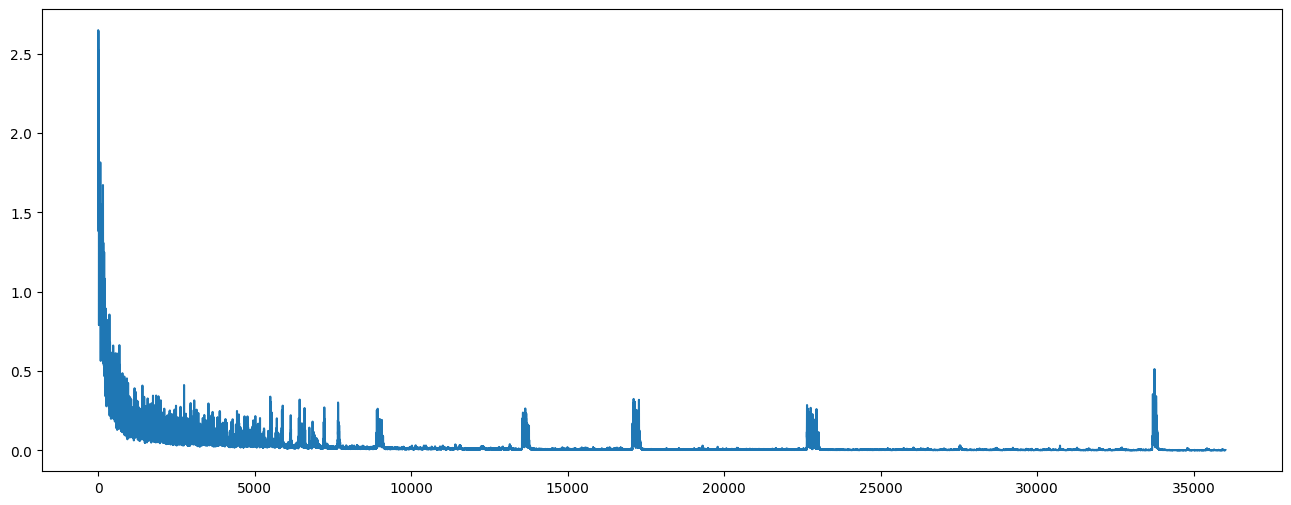

In [30]:
plt.figure(figsize=(16, 6))
plt.plot(trainer.train_history)
plt.show()

## Model Management: Keeping Best Models & Loading the Best Checkpoint

### **1. Overview**
To manage and efficiently store trained models, we:
1. **Extract loss values from filenames**.
2. **Compute a weighted combined loss**.
3. **Keep only the best-performing models**.
4. **Load the best checkpoint for inference/testing**.

---

### **2. Functions**
#### **a) `parse_loss_from_filename(filename)`**
- Extracts **position, velocity, and angular velocity errors** from model filenames.
- Expected format:

In [ ]:
def parse_loss_from_filename(filename):
    """
    Extracts position, velocity, and angular velocity losses from a model filename.

    Expected filename format:
    'GenLoss_<pos_loss>m_<vel_loss>mps_<angvel_loss>Nms2.pth'

    Parameters:
    - filename (str): Model filename.

    Returns:
    - pos_loss (float): Position error.
    - vel_loss (float): Velocity error.
    - angvel_loss (float): Angular velocity error.
    """
    parts = filename.split("_")
    pos_loss = float(parts[1].replace("m", ""))
    vel_loss = float(parts[2].replace("mps", ""))
    angvel_loss = float(parts[3].replace("Nms2.pth", ""))
    return pos_loss, vel_loss, angvel_loss


def combined_loss(
    pos_loss, vel_loss, angvel_loss, pos_weight=1.0, vel_weight=1.0, angvel_weight=1.0
):
    """
    Computes the weighted combined loss from position, velocity, and angular velocity errors.

    Parameters:
    - pos_loss (float): Position loss.
    - vel_loss (float): Velocity loss.
    - angvel_loss (float): Angular velocity loss.
    - pos_weight (float): Weight for position loss (default = 1.0).
    - vel_weight (float): Weight for velocity loss (default = 1.0).
    - angvel_weight (float): Weight for angular velocity loss (default = 1.0).

    Returns:
    - float: Weighted sum of losses.
    """
    return pos_weight * pos_loss + vel_weight * vel_loss + angvel_weight * angvel_loss


def keep_top_models(
    model_dir, top_n=20, pos_weight=1.0, vel_weight=1.0, angvel_weight=1.0
):
    """
    Retains only the top `top_n` best models based on their weighted combined loss and removes the rest.

    Parameters:
    - model_dir (str): Directory where model files are stored.
    - top_n (int): Number of top models to keep (default = 20).
    - pos_weight (float): Weight for position loss.
    - vel_weight (float): Weight for velocity loss.
    - angvel_weight (float): Weight for angular velocity loss.

    Deletes:
    - All models except the top `top_n` models.
    """
    if not os.path.exists(model_dir):
        print("Model directory does not exist.")
        return

    # Get list of all saved models
    model_files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]

    if not model_files:
        print("No model files found.")
        return

    # Extract losses from filenames and sort models by combined loss
    model_files.sort(
        key=lambda x: combined_loss(
            *parse_loss_from_filename(x), pos_weight, vel_weight, angvel_weight
        )
    )

    # Keep only the top `top_n` models and delete the rest
    for model_file in model_files[top_n:]:
        os.remove(os.path.join(model_dir, model_file))
        # print(f"Deleted {model_file}")


def load_best_model(trainer, pos_weight=1.0, vel_weight=1.0, angvel_weight=0.0):
    """
    Loads the best model based on the lowest weighted combined loss.

    Parameters:
    - trainer (Trainer): Instance of the `Trainer` class.
    - pos_weight (float): Weight for position loss.
    - vel_weight (float): Weight for velocity loss.
    - angvel_weight (float): Weight for angular velocity loss.

    Returns:
    - None (Updates trainer.model with the best model).
    """
    if not os.path.exists(trainer.model_dir):
        print("Model directory does not exist.")
        return

    # List all model files
    files = os.listdir(trainer.model_dir)

    # Filter models with the correct naming convention
    model_files = [
        file for file in files if file.startswith("GenLoss_") and file.endswith(".pth")
    ]

    if not model_files:
        print("No model files found in the directory.")
        return

    # Compute combined loss for each model
    combined_losses = [
        combined_loss(
            *parse_loss_from_filename(file), pos_weight, vel_weight, angvel_weight
        )
        for file in model_files
    ]

    # Convert to numpy array for easy processing
    combined_losses = np.array(combined_losses)

    # Identify the model with the minimum combined loss
    min_loss_index = np.argmin(combined_losses)
    min_loss_file = model_files[min_loss_index]

    print(f"Loading best model: {min_loss_file}")

    # Construct the full path to the best model
    path = os.path.join(trainer.model_dir, min_loss_file)

    # Load the model weights
    trainer.model.load_state_dict(torch.load(path))


# Keep only top 20 models
keep_top_models(trainer.model_dir, top_n=5)

# Load the best model for evaluation
load_best_model(trainer)

Loading best model: GenLoss_3.47m_0.10mps_1.04Nms2.pth


# Test for a single 
## Evaluating a Single Model Prediction Against Ground Truth

### **Objective**
This script compares:
- **Predicted acceleration** (`a_t`) vs. **Ground truth acceleration**.
- **Predicted stress tensor** (`σ_t`) vs. **Ground truth stress tensor**.

---

### **Steps**
1. **Extract a single batch** from `test_dataloader`.
2. **Move data to GPU (if available)** for faster computation.
3. **Create input graph** for the model using `create_input_graph()`.
4. **Obtain predictions** for acceleration and stress tensor.
5. **Rescale predictions** back to the original scale.
6. **Compute absolute errors** and **Mean Absolute Errors (MAE)**.

In [32]:
# Fetch a single batch (previous, current, next time step)
prev, cur, nxt = next(iter(test_dataloader))

# Move graphs to the trainer's device
prev, cur, nxt = prev.to(trainer.device), cur.to(trainer.device), nxt.to(trainer.device)

# Create input graph for the model
ingph = create_input_graph(prev, cur, trainer.device, stat_in_feat)

# Model prediction
pred_node_acc, pred_node_stress = trainer.model(ingph)

# Ground truth values from the next time step
true_node_acc = nxt.y_acc_t.to(trainer.device)  # True acceleration
true_node_stress = nxt.y_sig_t.to(trainer.device)  # True stress tensor

# Extract output feature statistics for re-scaling
(std_acc, mean_acc), (std_sig, mean_sig) = stat_out_feat
std_acc, mean_acc = std_acc.to(trainer.device), mean_acc.to(trainer.device)
std_sig, mean_sig = std_sig.to(trainer.device), mean_sig.to(trainer.device)

# Rescale predictions to original scale
pred_node_acc_rescaled = pred_node_acc * std_acc + mean_acc
pred_node_stress_rescaled = pred_node_stress * std_sig + mean_sig

# Compute absolute errors
error_acc = torch.abs(pred_node_acc_rescaled - true_node_acc)
error_stress = torch.abs(pred_node_stress_rescaled - true_node_stress)

# Compute Mean Absolute Errors (MAE)
mae_acc = torch.mean(error_acc).item()
mae_stress = torch.mean(error_stress).item()

# Print the results
print(f"Single Prediction Evaluation:")
print(f"Mean Absolute Error (Acceleration): {mae_acc:.6f}")
print(f"Mean Absolute Error (Stress Tensor): {mae_stress:.6f}")

Single Prediction Evaluation:
Mean Absolute Error (Acceleration): 0.036095
Mean Absolute Error (Stress Tensor): 0.085375


## Model Rollout & Ground Truth Comparison

### **Objective**
- This script **performs a multi-step rollout using the trained model**.
- It **compares the predicted acceleration** with the **ground truth acceleration** over time.
- It also **visualizes the stress tensor components** across multiple timesteps.

---

### **Steps**
1. **Run the `test()` function** to obtain predicted graph rollouts.
2. **Extract acceleration and stress tensor predictions**.
3. **Compare predictions with ground truth** from the test dataset.
4. **Plot acceleration components (`X, Y, Z`)** over time.
5. **Plot all nine stress tensor components (`σ11, σ12, σ13, σ21, σ22, σ23, σ31, σ32, σ33`)** in a **3x3 grid**.

---

### **Expected Output**
#### **Plot 1: Acceleration Evolution**
A **1x3 grid of plots** showing:
- **X-Axis acceleration** over time of tip node.
- **Y-Axis acceleration** over time of tip node.
- **Z-Axis acceleration** over time of tip node.

Each plot compares:
- **Model-predicted acceleration** (dashed line with stars `*--`).
- **Ground truth acceleration** (dashed line with circles `o-`).

#### **Plot 2: Stress Tensor Evolution**
A **3x3 grid of subplots** showing:
- **All nine stress tensor components** (`σ11, σ12, σ13, σ21, σ22, σ23, σ31, σ32, σ33`).
- Each component's **predicted vs. ground truth values over multiple time steps**.

---

Tip Node Index Selected: 68


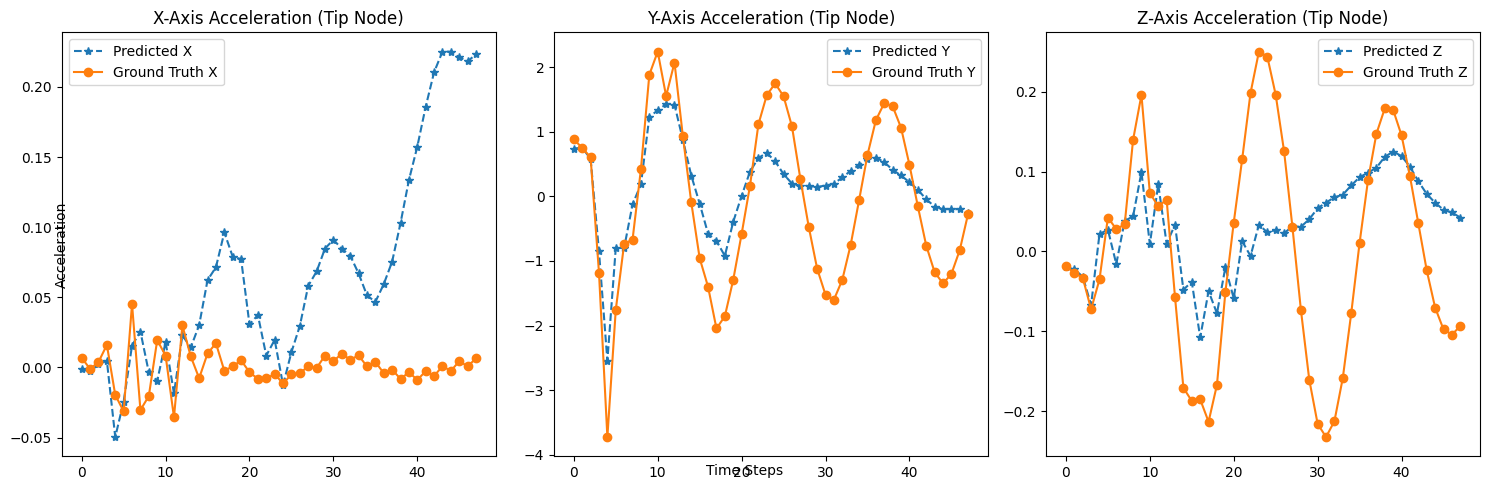

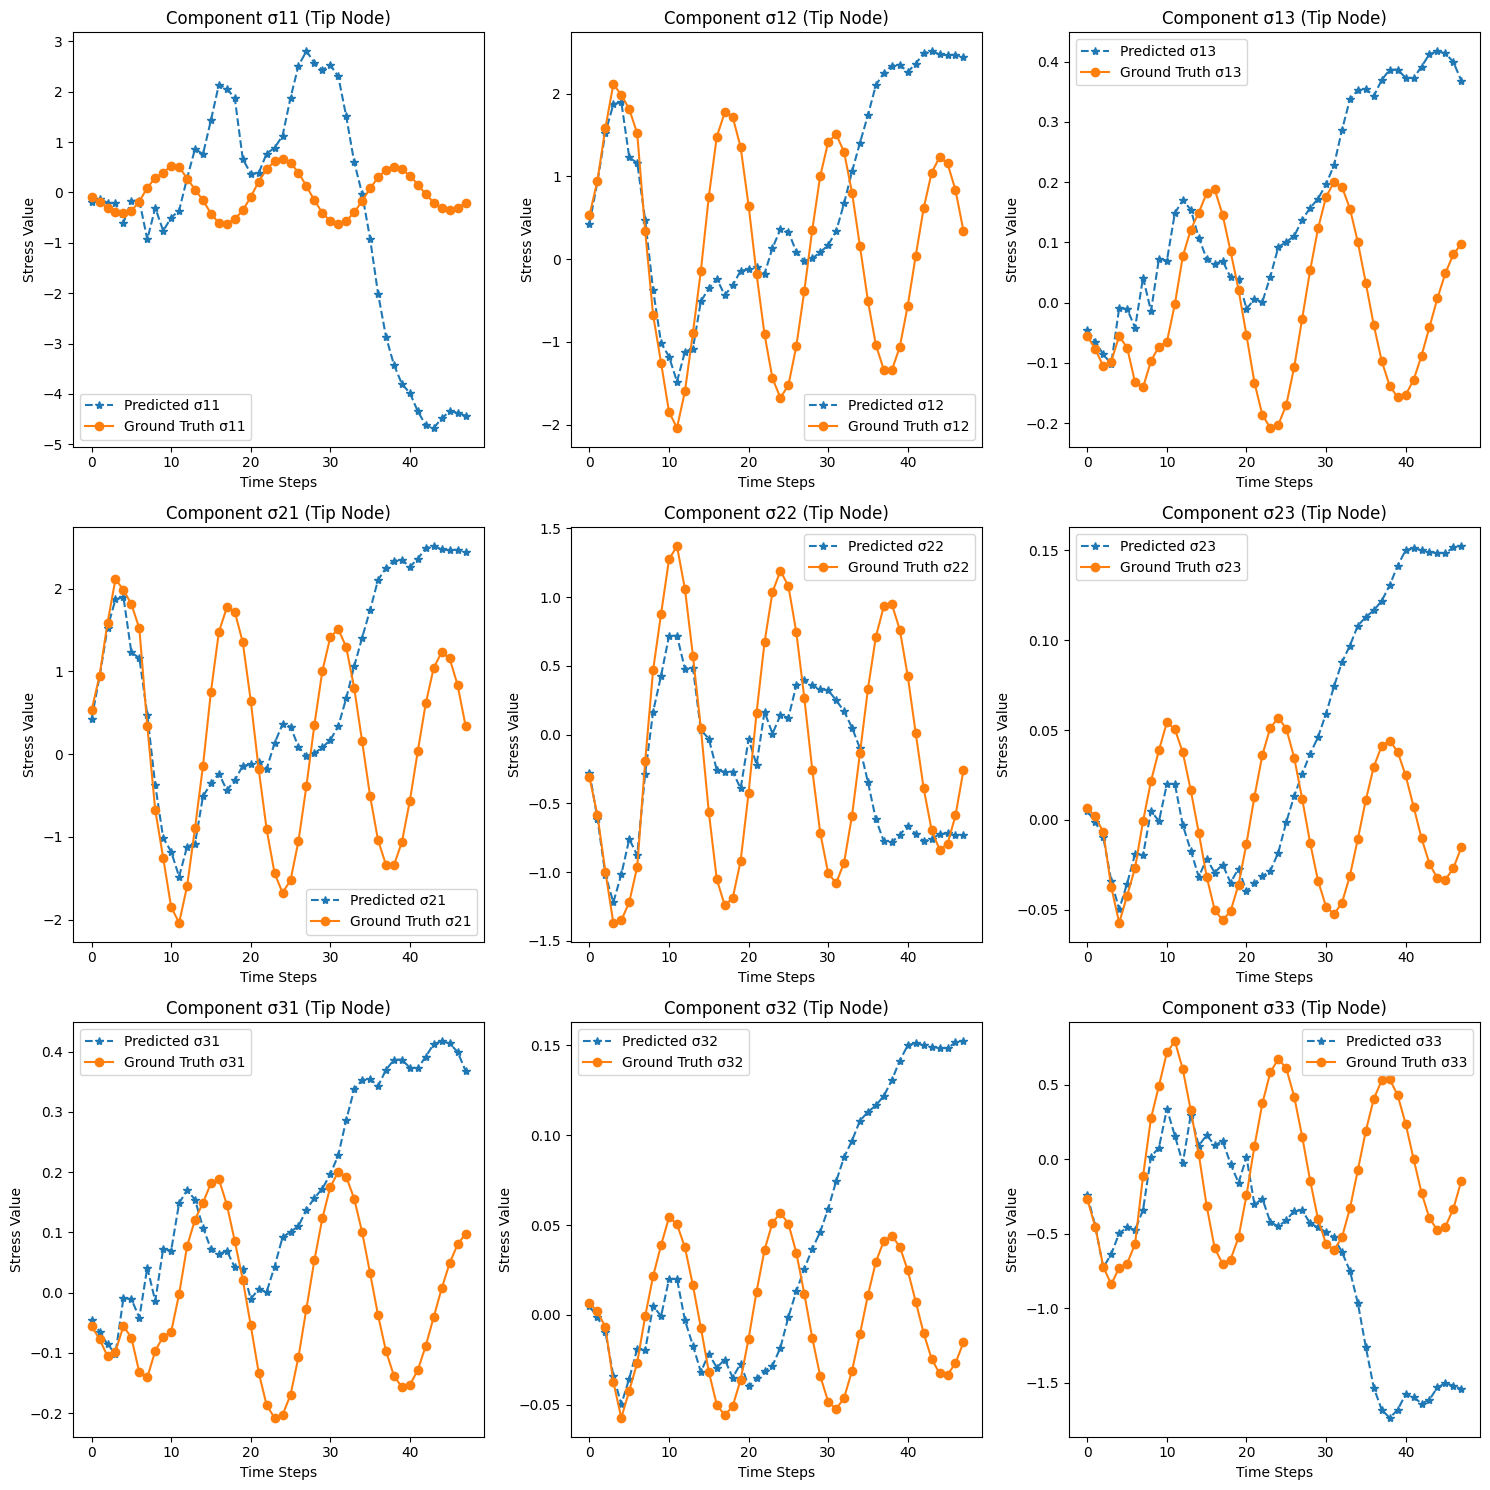

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Run the updated test function to get rollout predictions and errors
pred_graphs, true_graphs, lst_error_pos, lst_error_vel, lst_error_stress = test(
    test_dataloader,
    trainer.model,
    trainer.device,
    trainer.stat_in_feat,
    trainer.stat_out_feat,
    gen_roll_out=True,
    experiment_name="Test_Rollout",
)

# Extract acceleration and stress tensor predictions over multiple timesteps
pred_acc_rollout = []
true_acc_rollout = []
pred_stress_rollout = []
true_stress_rollout = []

# Iterate through the predicted graphs and extract acceleration & stress predictions
for pred_graph, true_graph in zip(pred_graphs, true_graphs):
    pred_acc_rollout.append(
        pred_graph.y_acc_t.cpu().detach().numpy()
    )  # Predicted acceleration
    true_acc_rollout.append(
        true_graph.y_acc_t.cpu().detach().numpy()
    )  # Ground truth acceleration

    pred_stress_rollout.append(
        pred_graph.y_sig_t.cpu().detach().numpy()
    )  # Predicted stress tensor
    true_stress_rollout.append(
        true_graph.y_sig_t.cpu().detach().numpy()
    )  # Ground truth stress tensor

# Convert to numpy arrays for visualization
pred_acc_rollout = np.array(pred_acc_rollout)  # Shape: (num_steps, num_nodes, 3)
true_acc_rollout = np.array(true_acc_rollout)  # Shape: (num_steps, num_nodes, 3)

pred_stress_rollout = np.array(pred_stress_rollout)  # Shape: (num_steps, num_nodes, 9)
true_stress_rollout = np.array(true_stress_rollout)  # Shape: (num_steps, num_nodes, 9)

## -------------------------------------
## SELECTING THE TIP NODE (EXTREME POSITION IN X, Y, Z)
## -------------------------------------

# Extract the last predicted graph to find the tip node
final_pred_graph = pred_graphs[-1]

# Convert position tensor to numpy for indexing
final_positions = final_pred_graph.x.cpu().detach().numpy()  # Shape: (num_nodes, 3)

# Find indices of the nodes with maximum X, Y, and Z positions
tip_node_x = np.argmax(final_positions[:, 0])  # Node with max X position
tip_node_y = np.argmax(final_positions[:, 1])  # Node with max Y position
tip_node_z = np.argmax(final_positions[:, 2])  # Node with max Z position

# Select the final tip node based on the maximum of all three axes
tip_node_idx = np.argmax(
    final_positions[:, 0] + final_positions[:, 1] + final_positions[:, 2]
)

print(f"Tip Node Index Selected: {tip_node_idx}")

## -------------------------------------
## PLOT 1: ACCELERATION ROLLOUT (X, Y, Z) for the Tip Node
## -------------------------------------

# Create a 1x3 grid of subplots for x, y, and z acceleration components
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot predicted vs. ground truth acceleration for the X-axis
ax[0].plot(pred_acc_rollout[:, tip_node_idx, 0], "*--", label="Predicted X")
ax[0].plot(true_acc_rollout[:, tip_node_idx, 0], "o-", label="Ground Truth X")
ax[0].set_title("X-Axis Acceleration (Tip Node)")
ax[0].legend()

# Plot predicted vs. ground truth acceleration for the Y-axis
ax[1].plot(pred_acc_rollout[:, tip_node_idx, 1], "*--", label="Predicted Y")
ax[1].plot(true_acc_rollout[:, tip_node_idx, 1], "o-", label="Ground Truth Y")
ax[1].set_title("Y-Axis Acceleration (Tip Node)")
ax[1].legend()

# Plot predicted vs. ground truth acceleration for the Z-axis
ax[2].plot(pred_acc_rollout[:, tip_node_idx, 2], "*--", label="Predicted Z")
ax[2].plot(true_acc_rollout[:, tip_node_idx, 2], "o-", label="Ground Truth Z")
ax[2].set_title("Z-Axis Acceleration (Tip Node)")
ax[2].legend()

# Add a common x-label and y-label
fig.text(0.5, 0.04, "Time Steps", ha="center")
fig.text(0.04, 0.5, "Acceleration", va="center", rotation="vertical")

# Show the acceleration plot
plt.tight_layout()
plt.show()

## -------------------------------------
## PLOT 2: STRESS TENSOR ROLLOUT (σ COMPONENTS - 3x3 Grid) for the Tip Node
## -------------------------------------

# Define labels for each of the 9 elements of the stress tensor
stress_labels = ["σ11", "σ12", "σ13", "σ21", "σ22", "σ23", "σ31", "σ32", "σ33"]

# Create a 3x3 grid of subplots for stress tensor components
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

# Flatten the axes array for easier iteration
ax = ax.flatten()

# Loop over each component of the stress tensor
for i in range(9):
    # Plot the predicted stress component
    ax[i].plot(
        pred_stress_rollout[:, tip_node_idx, i],
        "*--",
        label=f"Predicted {stress_labels[i]}",
    )

    # Plot the ground truth stress component
    ax[i].plot(
        true_stress_rollout[:, tip_node_idx, i],
        "o-",
        label=f"Ground Truth {stress_labels[i]}",
    )

    # Set the title and legend for each subplot
    ax[i].set_title(f"Component {stress_labels[i]} (Tip Node)")
    ax[i].legend()
    ax[i].set_xlabel("Time Steps")
    ax[i].set_ylabel("Stress Value")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# **Beam Comparison GIF Generator**
## **Function: `make_beam_comparison_gif()`**
This function generates a **single animated GIF** where each frame consists of **side-by-side 3D plots**:
- **Left:** Ground Truth Beam
- **Right:** Predicted Beam

### **🔹 Parameters**
| **Parameter**      | **Type**     | **Description** |
|--------------------|-------------|----------------|
| `lst_pred_graphs` | `list[Data]` | List of **predicted** beam deformation states. |
| `lst_true_graphs` | `list[Data]` | List of **ground truth** beam deformation states. |
| `L, W, D`         | `float`      | Beam dimensions (for aspect ratio). |
| `out_gif`         | `str`        | Output filename (e.g., `"beam_comparison.gif"`). |
| `fps`             | `int`        | Frames per second (default = 4). |

### **🔹 Features**
 Uses **tetrahedral element connectivity** to interpolate stress.  

### **🔹 Example Usage**
```python
make_beam_comparison_gif(
    lst_pred_graphs=pred_graphs, 
    lst_true_graphs=true_graphs, 
    L=1.0, W=0.1, D=0.04, 
    out_gif="beam_comparison.gif",
    fps=4
)


In [ ]:
def compute_von_mises_3d(stress_9):
    sxx = stress_9[:, 0]
    sxy = stress_9[:, 1]
    sxz = stress_9[:, 2]
    syx = stress_9[:, 3]
    syy = stress_9[:, 4]
    syz = stress_9[:, 5]
    szx = stress_9[:, 6]
    szy = stress_9[:, 7]
    szz = stress_9[:, 8]
    vm = 0.5 * (
        (sxx - syy) ** 2
        + (syy - szz) ** 2
        + (szz - sxx) ** 2
        + 6.0 * (sxy**2 + syz**2 + sxz**2)
    )
    return np.sqrt(vm)


def make_beam_comparison_gif(lst_pred_graphs, lst_true_graphs, L, W, D, out_gif, fps=4):
    """
    Generates a single GIF where each frame contains two side-by-side 3D plots:
    - Left: Ground Truth Beam
    - Right: Predicted Beam

    Uses element connectivity to interpolate stress values.

    Parameters:
    - lst_pred_graphs: List of predicted PyG Data objects.
    - lst_true_graphs: List of ground truth PyG Data objects.
    - L, W, D: Beam dimensions (used for aspect ratio).
    - out_gif: Output GIF filename.
    - fps: Frames per second.
    """
    assert len(lst_pred_graphs) == len(lst_true_graphs), (
        "Mismatch in predicted and ground truth frames."
    )

    temp_dir = "temp_frames"
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir, exist_ok=True)

    frames = []

    # Extract element connectivity from the first graph: it's an Nx4 array showing 4 nodes of the tetrahedral mesh element for each node.
    first_graph = lst_true_graphs[0]
    cells = first_graph.x_element_connectivity[0][
        0
    ]  # it was a mistake that x_element_connectivity was stored as a nested list

    # Find global bounding box across all frames
    all_x, all_y, all_z = [], [], []
    vm_min, vm_max = 0.0, 0.0  # Stress range

    for g_pred, g_true in zip(lst_pred_graphs, lst_true_graphs):
        coords_pred = g_pred.x.cpu().numpy()
        coords_true = g_true.x.cpu().numpy()
        all_x.extend(coords_pred[:, 0])
        all_y.extend(coords_pred[:, 1])
        all_z.extend(coords_pred[:, 2])
        all_x.extend(coords_true[:, 0])
        all_y.extend(coords_true[:, 1])
        all_z.extend(coords_true[:, 2])

        vm_max = max(vm_max, np.max(compute_von_mises_3d(g_pred.y_sig_t.cpu().numpy())))
        vm_max = max(vm_max, np.max(compute_von_mises_3d(g_true.y_sig_t.cpu().numpy())))

    x_min, x_max = np.min(all_x), np.max(all_x)
    y_min, y_max = np.min(all_y), np.max(all_y)
    z_min, z_max = np.min(all_z), np.max(all_z)

    # Iterate over time steps to create frames
    for i, (graph_pred, graph_true) in enumerate(zip(lst_pred_graphs, lst_true_graphs)):
        print(f"Rendering frame {i}/{len(lst_pred_graphs) - 1}")

        coords_pred = graph_pred.x.cpu().numpy()
        coords_true = graph_true.x.cpu().numpy()

        stress_pred = graph_pred.y_sig_t.cpu().numpy()
        stress_true = graph_true.y_sig_t.cpu().numpy()

        vm_pred = compute_von_mises_3d(stress_pred)
        vm_true = compute_von_mises_3d(stress_true)

        fig, axarr = plt.subplots(
            1, 2, figsize=(16, 8), subplot_kw={"projection": "3d"}
        )

        cmap = plt.cm.jet
        norm = plt.Normalize(vmin=vm_min, vmax=vm_max)

        # Function to plot a beam in 3D with element connectivity
        def plot_beam(ax, coords, vm, title):
            polys = []
            face_values = []
            for tet in cells:
                tet_coords = coords[tet]  # No offset needed for separate subplots
                polys.append(tet_coords[:3])  # Use first 3 vertices for a face
                face_values.append(np.mean(vm[tet]))  # Interpolated stress

            face_values = np.array(face_values)
            face_colors = cmap(norm(face_values))

            polycoll = Poly3DCollection(polys)
            polycoll.set_facecolors(face_colors)
            polycoll.set_edgecolor("none")
            ax.add_collection3d(polycoll)

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_zlim(z_min, z_max)

            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_zlabel("Z")

            ax.set_box_aspect((L * 0.1, 0.8 * W, 2.5 * D))
            ax.view_init(elev=30, azim=45)
            ax.set_title(title)

        # Left subplot: Ground Truth
        plot_beam(axarr[0], coords_true, vm_true, title="Ground Truth")

        # Right subplot: Predicted
        plot_beam(axarr[1], coords_pred, vm_pred, title="Predicted MeshGraphNet")

        cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # (left, bottom, width, height)
        cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
        cbar.set_label("von Mises Stress")
        # cb = fig.colorbar(mappable, ax=axarr.ravel().tolist(), shrink=0.6)
        # cb.set_label("von Mises Stress")

        frame_path = os.path.join(temp_dir, f"frame_{i:03d}.png")
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        plt.savefig(frame_path, dpi=100)
        plt.close(fig)

        frames.append(imageio.imread(frame_path))

    # Create GIF
    imageio.mimsave(out_gif, frames, fps=fps, loop=0)
    print(f"GIF saved => {out_gif}")

    # Cleanup
    shutil.rmtree(temp_dir)
    print("Done.")

In [ ]:
make_beam_comparison_gif(
    lst_pred_graphs=pred_graphs,
    lst_true_graphs=true_graphs,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/47


/tmp/ipykernel_2366641/2810005022.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])
/tmp/ipykernel_2366641/2810005022.py:132: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))


Rendering frame 1/47
Rendering frame 2/47
Rendering frame 3/47
Rendering frame 4/47
Rendering frame 5/47
Rendering frame 6/47
Rendering frame 7/47
Rendering frame 8/47
Rendering frame 9/47
Rendering frame 10/47
Rendering frame 11/47
Rendering frame 12/47
Rendering frame 13/47
Rendering frame 14/47
Rendering frame 15/47
Rendering frame 16/47
Rendering frame 17/47
Rendering frame 18/47
Rendering frame 19/47
Rendering frame 20/47
Rendering frame 21/47
Rendering frame 22/47
Rendering frame 23/47
Rendering frame 24/47
Rendering frame 25/47
Rendering frame 26/47
Rendering frame 27/47
Rendering frame 28/47
Rendering frame 29/47
Rendering frame 30/47
Rendering frame 31/47
Rendering frame 32/47
Rendering frame 33/47
Rendering frame 34/47
Rendering frame 35/47
Rendering frame 36/47
Rendering frame 37/47
Rendering frame 38/47
Rendering frame 39/47
Rendering frame 40/47
Rendering frame 41/47
Rendering frame 42/47
Rendering frame 43/47
Rendering frame 44/47
Rendering frame 45/47
Rendering frame 46/

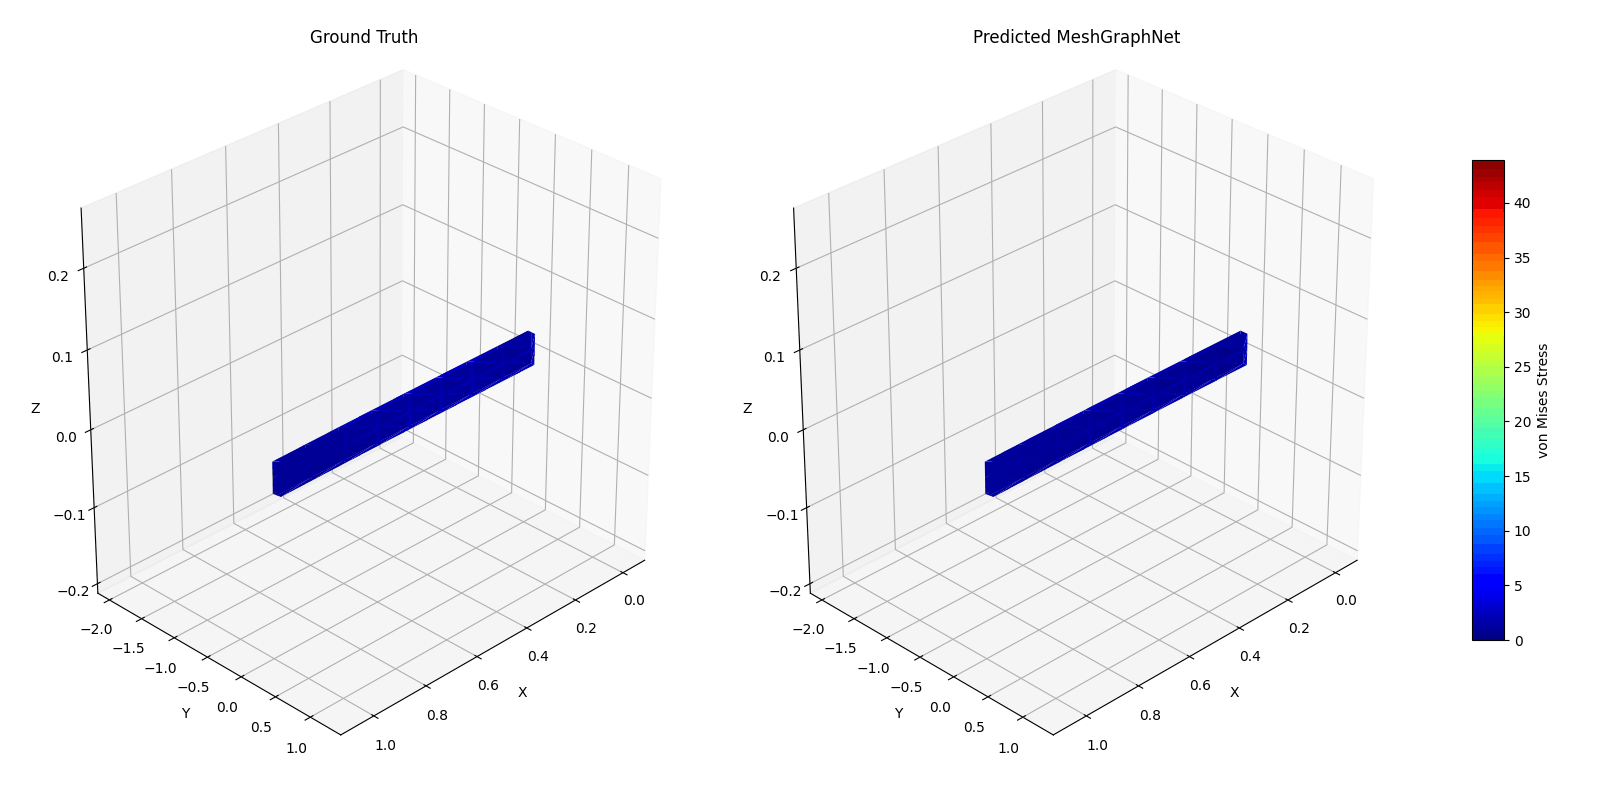

In [ ]:
from IPython.display import Image

Image(filename="beam_comparison.gif")